# Импорт библиотек и настройка среды

In [254]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [214]:
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Вспомогательные функции

## Функция создания labels для cut разделения

In [215]:
def make_labels(
    segments: list[float]
) -> list[str]:
    labels = []
    
    for i in range(len(segments) - 1):
        left = segments[i]
        right = segments[i + 1]

        if i == 0:
            labels.append(f"[{left}, {right}]")
        else:
            labels.append(f"({left}, {right}]")

    return labels

## Функция создания новых столбцов признака

In [216]:
def make_segments_cols(
    data: pd.DataFrame,
    feature: str,
    segments: list[float],
    special_values: list[int] = []
) -> pd.DataFrame:
    df = data.copy(deep=True)

    labels = make_labels(segments)

    segment_col_name = f"{feature}_segments"

    df[segment_col_name] = pd.cut(
        x=df[feature].dropna(),
        labels=labels,
        bins=segments,
        right=True,
        include_lowest=True
    )

    special_labels = []
    if special_values:
        for special_value in special_values:
            label = str(special_value)

            special_labels.append(label)

        new_categories = [
            label
            for label in special_labels
            if label not in df[segment_col_name].cat.categories
        ]

        df[segment_col_name] = (
            df[segment_col_name]
            .cat.add_categories(new_categories)
        )

        for special_value in special_values:
            mask = df[feature].eq(special_value)
            label = str(special_value)

            df.loc[mask, segment_col_name] = label

    cols = pd.get_dummies(
        df[segment_col_name],
        prefix=f"{feature}"
    )

    return cols
    

## Функция подготовки датасета

In [217]:
def prepare_dataset(
    data: pd.DataFrame,
    features: list[str],
    segmentss: list[list[float]],
    special_valuess: list[list[float]]
) -> pd.DataFrame:
    df = data.copy(deep=True)

    for feature, segments, special_values in zip(
        features,
        segmentss,
        special_valuess
    ):
        cols = make_segments_cols(
            data=df,
            feature=feature,
            segments=segments,
            special_values=special_values
        )

        df = df.drop(columns=feature)
        df = pd.concat([df, cols], axis=1)

    return df

## Функция оценки модели

In [218]:
def evaluate_ranking(model, X, y) -> dict[str, float]:
    y_score = model.predict_proba(X)[:, 1]

    roc_auc = roc_auc_score(y, y_score)
    pr_auc = average_precision_score(y, y_score)

    fpr, tpr, _ = roc_curve(y, y_score)
    ks = np.max(tpr - fpr)

    return {
        "roc_auc": roc_auc,
        "gini": 2 * roc_auc - 1,
        "ks": ks,
        "pr_auc": pr_auc,
    }

## ROC Curves: Logistic Regression vs CatBoost

In [259]:
def roc_curves(
    logistic_regression,
    catboost_classifier
) -> None:
    logistic_score = logistic_regression.predict_proba(X_t_test)[:, 1]
    catboost_score = catboost_classifier.predict_proba(X_test)[:, 1]

    logistic_fpr, logistic_tpr, _ = roc_curve(
        y_test,
        logistic_score
    )
    catboost_fpr, catboost_tpr, _ = roc_curve(
        y_test,
        catboost_score
    )

    logistic_auc = roc_auc_score(
        y_test,
        logistic_score
    )
    catboost_auc = roc_auc_score(
        y_test,
        catboost_score
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(
        logistic_fpr,
        logistic_tpr,
        label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
    )

    ax.plot(
        catboost_fpr,
        catboost_tpr,
        label=f"CatBoost (AUC = {catboost_auc:.3f})"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random classifier"
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — Logistic Regression vs CatBoost")
    ax.legend()
    ax.grid(alpha=0.25)

    plt.show()

## Observed Bad Rate by Risk Decile

In [265]:
def observed_bad_rate_by_risk_decile(
    risk_groups: pd.DataFrame
) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(
        risk_groups["risk_group"].astype(str),
        risk_groups["observed_bad_rate"] * 100
    )

    ax.bar_label(
        bars,
        labels=[
            f"{value:.1f}%"
            for value in risk_groups["observed_bad_rate"] * 100
        ],
        padding=3
    )

    ax.set_xlabel("Risk Decile")
    ax.set_ylabel("Observed Bad Rate, %")
    ax.set_title("Observed Bad Rate by Predicted Risk Decile")

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.show()

## Top Logistic Regression Coefficients

In [267]:
def top_logistic_regression_coefficients(
    weights_classes: pd.DataFrame
) -> None:
    top_n = 15

    top_coefficients = (
        weights_classes
        .nlargest(top_n, "weights_abs")
        .sort_values("weights")
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.barh(
        top_coefficients["classes"],
        top_coefficients["weights"]
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_xlabel("Logistic Regression Coefficient")
    ax.set_ylabel("Feature / Segment")
    ax.set_title(f"Top {top_n} Logistic Regression Coefficients")

    ax.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

# Цель

Цель notebook — построить risk score, который ранжирует заёмщиков от менее рискованных к более рискованным, и проверить, даёт ли более сложная модель заметное улучшение качества ранжирования относительно интерпретируемой Logistic Regression.

Для этого необходимо:

1. Зафиксировать development и final holdout samples.
2. Построить Logistic Regression baseline и определить подходящее представление признаков.
3. Построить CatBoost challenger на тех же development и holdout выборках.
4. Сравнить модели по ROC-AUC, Gini, KS и PR-AUC.
5. Проинтерпретировать коэффициенты Logistic Regression как дополнительный sanity check модели.
6. Для выбранной модели проверить, соответствует ли рост predicted risk росту observed bad rate.
7. Подготовить borrower-level scores для последующего SQL-анализа и portfolio risk segmentation.

# Методология

1. **Подготовка данных**

    1. Исходный датасет разделяется на train, validation и final holdout по индексам, чтобы все сравниваемые модели оценивались на одних и тех же наблюдениях.
    2. Для Logistic Regression рассматриваются два представления признаков: исходные очищенные признаки и дискретизированные признаки, построенные на основе ранее выявленных нелинейных risk patterns.
    3. CatBoost обучается на очищенных исходных признаках без предварительной дискретизации, поскольку tree-based boosting способен самостоятельно моделировать нелинейные зависимости и пороговые эффекты.

2. **Logistic Regression baseline**

    1. На validation sample сравнивается качество Logistic Regression на исходном и дискретизированном представлениях признаков.
    2. Для выбранного представления подбираются гиперпараметры на development data.
    3. Финальная Logistic Regression обучается на объединённой train + validation выборке.
    4. Итоговое качество оценивается один раз на final holdout.

3. **CatBoost challenger**

    1. Гиперпараметры CatBoost подбираются на development data.
    2. Финальная модель обучается на той же объединённой train + validation выборке.
    3. Качество оценивается на том же final holdout, что обеспечивает сопоставимость результатов с Logistic Regression.

4. **Сравнение моделей**

Модели сравниваются по threshold-independent метрикам ROC-AUC, Gini, KS и PR-AUC. На основании полученного прироста качества оценивается, оправдывает ли CatBoost дополнительную сложность относительно интерпретируемого Logistic Regression baseline.

5. **Интерпретация Logistic Regression**

Направления и величины основных коэффициентов Logistic Regression сопоставляются с risk patterns, выявленными в предыдущем анализе. Такое сопоставление используется как дополнительный sanity check согласованности модели, а не как доказательство причинных зависимостей или корректности предыдущего анализа.

6. **Risk ranking sanity check**

Клиенты final holdout распределяются по группам в соответствии с predicted risk выбранной модели. Если модель корректно ранжирует риск, observed bad rate должен в целом возрастать от низкорисковых групп к высокорисковым.

7. **Подготовка scores**

Borrower-level scores выбранной модели используются далее для SQL-анализа, risk segmentation и разработки credit-policy cutoffs.

# 1. Загрузка датасета и фиксирование train, val и test частей.

In [219]:
data = pd.read_csv("../data/interim/borrowers.csv")

train_idx, test_idx = train_test_split(
    data.index,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=data["target"]
)

train_idx, val_idx = train_test_split(
    data.loc[train_idx, :].index,
    test_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=data.loc[train_idx, "target"]
)

train = data.loc[train_idx]
val = data.loc[val_idx]
test = data.loc[test_idx]

# 1. Подготовка признаков

Сегменты признаков и их специальные значения.

In [220]:
features = [
    "revolving_utilization",
    "age",
    "num_30_59_days_late",
    "debt_ratio",
    "monthly_income",
    "num_open_credit_lines",
    "num_90_days_late",
    "num_real_estate_loans",
    "num_60_89_days_late",
    "num_dependents"
]

segmentss = [
    [0.0, 0.2, 0.4, 0.5, 0.7, 1.0, 2.0, 5.0, np.inf],
    [0.0, 22.0, 30.0, 45.0, 55.0, 75.0, np.inf],
    [1, 2, np.inf],
    [0.0, 0.1, 0.7, 1.0, 4.0, np.inf],
    [0.0, 900.0, 3000.0, 4500.0, 6500.0, 13000.0, np.inf],
    [1, 2, np.inf],
    [1, 2, np.inf],
    [1, 3, np.inf],
    [1, 2, np.inf],
    [1, 2, np.inf]
]

special_valuess = [
    [],
    [],
    [0, 96, 98],
    [0],
    [],
    [0],
    [0, 96, 98],
    [0],
    [0, 96, 98],
    [0]
]

Подготовка признаков.

In [221]:
transformed_train = prepare_dataset(
    data=train,
    features=features,
    segmentss=segmentss,
    special_valuess=special_valuess
)

In [222]:
transformed_val = prepare_dataset(
    data=val,
    features=features,
    segmentss=segmentss,
    special_valuess=special_valuess
)

In [223]:
transformed_test = prepare_dataset(
    data=test,
    features=features,
    segmentss=segmentss,
    special_valuess=special_valuess
)

**Разделение данных на X и target.**

Непреобразованные данные.

In [224]:
X_train = train.drop(columns="target").fillna(-1)
X_val = val.drop(columns="target").fillna(-1)
X_test = test.drop(columns="target").fillna(-1)

y_train = train["target"]
y_val = val["target"]
y_test = test["target"]

Преобразованные данные.

In [225]:
X_t_train = transformed_train.drop(columns="target")
X_t_val = transformed_val.drop(columns="target")
X_t_test = transformed_test.drop(columns="target")

y_t_train = transformed_train["target"]
y_t_val = transformed_val["target"]
y_t_test = transformed_test["target"]

# 2. Logistic Regression Baseline

## Определение типа датасета для baseline модели

Создание моделей.

In [226]:
model_on_base = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
model_on_transformed = LogisticRegression(max_iter=1000)

Обучение моделей.

In [227]:
model_on_base.fit(X_train, y_train)
model_on_transformed.fit(X_t_train, y_t_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Оценка качества на валидационной части.

In [228]:
model_on_base_metrics = evaluate_ranking(
    model=model_on_base,
    X=X_val,
    y=y_val
)
model_on_transformed_metrics = evaluate_ranking(
    model=model_on_transformed,
    X=X_t_val,
    y=y_t_val
)

In [229]:
model_on_base_metrics

{'roc_auc': 0.8088113820235403,
 'gini': 0.6176227640470806,
 'ks': np.float64(0.4651292219854113),
 'pr_auc': 0.33804415889225137}

In [230]:
model_on_transformed_metrics

{'roc_auc': 0.8513522062538241,
 'gini': 0.7027044125076483,
 'ks': np.float64(0.5460952492992333),
 'pr_auc': 0.37545181615986367}

На validation sample Logistic Regression на дискретизированных признаках показывает более высокое качество по всем рассматриваемым ranking metrics. ROC-AUC увеличивается примерно на 0.043, что подтверждает полезность выбранного feature transformation для линейной модели.

In [231]:
for item_base, item_transformed in zip(
    model_on_base_metrics.items(),
    model_on_transformed_metrics.items()
):
    print(f"delta {item_base[0]} = {item_transformed[1] - item_base[1]:.3f}")

delta roc_auc = 0.043
delta gini = 0.085
delta ks = 0.081
delta pr_auc = 0.037


## Подбор гиперпараметров для baseline модели

Функция вычисления оптимальных гиперпараметров.

In [232]:
def objective(trial):
    C = trial.suggest_float(
        "C",
        1e-3,
        10,
        log=True
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        [None, "balanced"]
    )

    model = LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        C=C,
        class_weight=class_weight,
        max_iter=1000,
        random_state=42
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    X = pd.concat([X_t_train, X_t_val], axis=0)
    y = pd.concat([y_t_train, y_t_val], axis=0)

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

Подбор гиперпараметров.

In [233]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=20
)

[I 2026-08-20 16:25:31,024] A new study created in memory with name: no-name-9cf5b372-395d-4b9e-963b-6e5059cdd880
[I 2026-08-20 16:25:41,542] Trial 0 finished with value: 0.8577298961230356 and parameters: {'C': 0.07469142800664595, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8577298961230356.
[I 2026-08-20 16:25:44,351] Trial 1 finished with value: 0.8563184294528965 and parameters: {'C': 0.006765255416321949, 'class_weight': None}. Best is trial 0 with value: 0.8577298961230356.
[I 2026-08-20 16:25:47,171] Trial 2 finished with value: 0.8575663070305948 and parameters: {'C': 0.015347478291119336, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8577298961230356.
[I 2026-08-20 16:25:48,213] Trial 3 finished with value: 0.8540670817256688 and parameters: {'C': 0.001593620530510357, 'class_weight': None}. Best is trial 0 with value: 0.8577298961230356.
[I 2026-08-20 16:25:49,921] Trial 4 finished with value: 0.857739994932792 and parameters: {'C': 0.196749412704

Сохранение гиперпараметров.

In [234]:
logistic_regression_best_params = study.best_params

## Итоговое обучение модели с подобранными гиперпараметрами и оценка её качества

Обучение модели.

In [235]:
logistic_regression = LogisticRegression(**logistic_regression_best_params, max_iter=1000, random_state=42)

In [236]:
X_t_train_ = pd.concat([X_t_train, X_t_val], axis=0)
y_t_train_ = pd.concat([y_t_train, y_t_val], axis=0)

logistic_regression.fit(X_t_train_, y_t_train_)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",9.975823351834283
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization pro

Оценка качества модели.

In [237]:
baseline_model_metrics = evaluate_ranking(
    model=logistic_regression,
    X=X_t_test,
    y=y_t_test
)

In [238]:
baseline_model_metrics

{'roc_auc': 0.8596505973969212,
 'gini': 0.7193011947938424,
 'ks': np.float64(0.5677965033242061),
 'pr_auc': 0.3809907256164006}

# 3. CatBoost Challenger

## Подбор параметров для CatBoost модели

Функция вычисления оптимальных гиперпараметров.

In [239]:
def objective(trial):
    model = CatBoostClassifier(
        iterations=trial.suggest_int(
            "iterations",
            300,
            700,
            step=100
        ),

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.02,
            0.08,
            log=True
        ),

        depth=trial.suggest_int(
            "depth",
            4,
            7
        ),

        l2_leaf_reg=trial.suggest_float(
            "l2_leaf_reg",
            3,
            12,
            log=True
        ),

        auto_class_weights=trial.suggest_categorical(
            "auto_class_weights",
            [None, "SqrtBalanced"]
        ),

        random_strength=1,

        loss_function="Logloss",
        random_seed=42,
        verbose=False,
        thread_count=1
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    X = pd.concat([X_train, X_val], axis=0)
    y = pd.concat([y_train, y_val], axis=0)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return scores.mean()

Подбор гиперпараметров.

In [240]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=20
)

[I 2026-08-20 16:26:11,511] A new study created in memory with name: no-name-62a6304a-b7d7-45c8-bb58-84bb2fb02bd4
[I 2026-08-20 16:26:27,786] Trial 0 finished with value: 0.8654991752279676 and parameters: {'iterations': 300, 'learning_rate': 0.034134406975839644, 'depth': 7, 'l2_leaf_reg': 4.333817220386065, 'auto_class_weights': None}. Best is trial 0 with value: 0.8654991752279676.
[I 2026-08-20 16:26:48,705] Trial 1 finished with value: 0.8656053210919351 and parameters: {'iterations': 400, 'learning_rate': 0.05263182744344588, 'depth': 7, 'l2_leaf_reg': 6.6636180350040375, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 1 with value: 0.8656053210919351.
[I 2026-08-20 16:27:21,009] Trial 2 finished with value: 0.8662092440159703 and parameters: {'iterations': 600, 'learning_rate': 0.030107266371258063, 'depth': 7, 'l2_leaf_reg': 10.387011986151355, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 2 with value: 0.8662092440159703.
[I 2026-08-20 16:27:43,733] Trial 3 finishe

Сохранение оптимальных гиперпараметров.

In [241]:
catboost_best_params = study.best_params

## Итоговое обучение модели с подобранными гиперпараметрами и оценка её качества

Обучение модели.

In [242]:
catboost_classifier = CatBoostClassifier(
    **catboost_best_params,
    random_strength=1,
    loss_function="Logloss",
    random_seed=42,
    verbose=False,
    thread_count=1
)

In [243]:
X_train_ = pd.concat([X_train, X_val], axis=0)
y_train_ = pd.concat([y_train, y_val], axis=0)

catboost_classifier.fit(X_train_, y_train_)

CatBoostClassifier(auto_class_weights='SqrtBalanced', depth=6, iterations=600, l2_leaf_reg=11.924051863462786, learning_rate=0.027822638424776388, loss_function='Logloss', random_seed=42, random_strength=1, thread_count=1, verbose=False)

Оценка качества модели.

In [244]:
challenger_model_metrics = evaluate_ranking(
    model=catboost_classifier,
    X=X_test,
    y=y_test
)

In [245]:
challenger_model_metrics

{'roc_auc': 0.8723864485702709,
 'gini': 0.7447728971405418,
 'ks': np.float64(0.5921835835638045),
 'pr_auc': 0.4069366538454407}

# 4. Сравнение моделей

Агрегация метрик качества моделей в единую таблицу.

In [246]:
models_metrics = pd.DataFrame(columns=["model", "ROC-AUC", "Gini", "KS", "PR-AUC"])

models_metrics.loc[ models_metrics.shape[0] ] = [
    "Logistic Regression",
    baseline_model_metrics["roc_auc"],
    baseline_model_metrics["gini"],
    baseline_model_metrics["ks"],
    baseline_model_metrics["pr_auc"]
]

models_metrics.loc[ models_metrics.shape[0] ] = [
    "CatBoost Classifier",
    challenger_model_metrics["roc_auc"],
    challenger_model_metrics["gini"],
    challenger_model_metrics["ks"],
    challenger_model_metrics["pr_auc"]
]

models_metrics.loc[ models_metrics.shape[0] ] = [
    "Delta PP",
    (challenger_model_metrics["roc_auc"] - baseline_model_metrics["roc_auc"]) * 100,
    (challenger_model_metrics["gini"] - baseline_model_metrics["gini"]) * 100,
    (challenger_model_metrics["ks"] - baseline_model_metrics["ks"]) * 100,
    (challenger_model_metrics["pr_auc"] - baseline_model_metrics["pr_auc"]) * 100
]

Сравнение моделей по метрикам качества.

In [247]:
models_metrics

,model,ROC-AUC,Gini,KS,PR-AUC
0,Logistic Regression,0.8597,0.7193,0.5678,0.3810
1,CatBoost Classifier,0.8724,0.7448,0.5922,0.4069
2,Delta PP,1.2736,2.5472,2.4387,2.5946


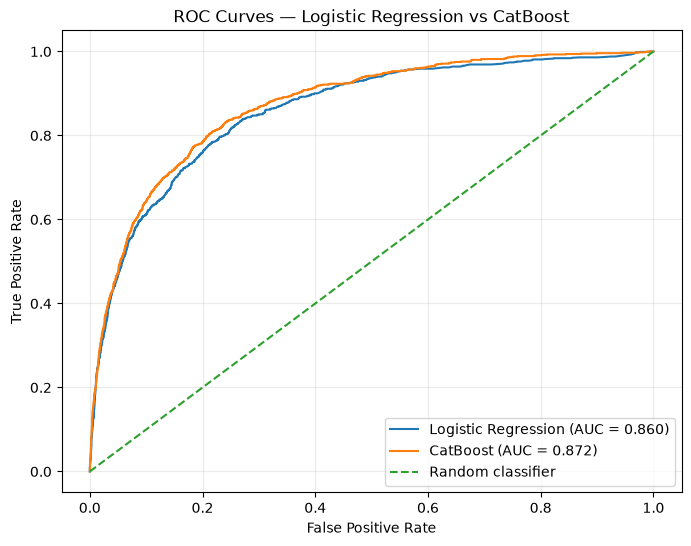

In [258]:
roc_curves(
    logistic_regression=logistic_regression,
    catboost_classifier=catboost_classifier
)

По сравнению с Logistic Regression, CatBoost повышает ROC-AUC на 1,27 процентного пункта, Gini на 2,55 п.п., KS на 2,44 п.п. и PR-AUC на 2,59 п.п. Улучшение наблюдается по всем рассматриваемым метрикам дискриминации, хотя в абсолютном выражении остаётся умеренным.

**Таким образом:**

**Logistic Regression:**

1. Высокая интерпретируемость.
2. Низкая вычислительная сложность.
3. Хорошее качество risk ranking, лишь умеренно уступающее CatBoost.

**CatBoostClassifier:**

1. Более низкая интерпретируемость.
2. Более высокая вычислительная сложность, которая для текущего объёма данных не является существенным ограничением.
3. Стабильно более высокое качество по всем рассматриваемым ranking metrics.

Для последующего ранжирования портфеля выбран CatBoost, поскольку на final holdout он демонстрирует стабильно более высокое качество дискриминации по всем рассматриваемым метрикам. Logistic Regression при этом сохраняется как интерпретируемый baseline для сопоставления и анализа основных risk drivers.

# 5. Интерпретация Logistic Regression

Получим веса модели логистической регрессии и поместим их в удобную таблицу.

In [248]:
X_train.shape

(108000, 14)

In [249]:
weights_classes = pd.DataFrame({
    "classes": X_t_train.columns,
    "weights_abs": list(map(abs, logistic_regression.coef_[0])),
    "weights": logistic_regression.coef_[0]
}).sort_values(by="weights_abs", ascending=False).reset_index(drop=True)

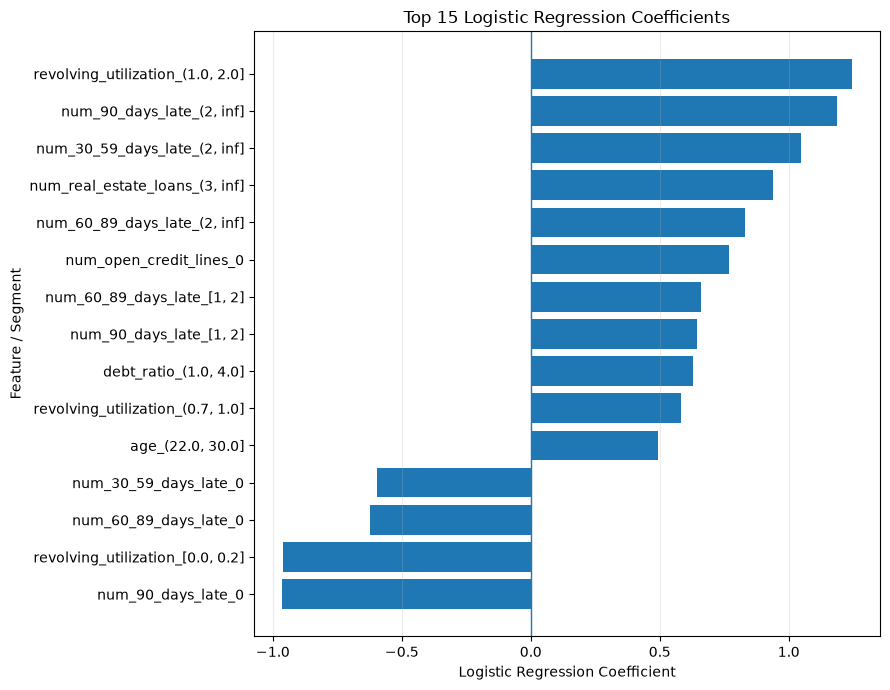

In [268]:
top_logistic_regression_coefficients(weights_classes=weights_classes)

Для интерпретации направления эффектов:

При прочих равных положительные коэффициенты Logistic Regression связаны с более высоким predicted risk, а отрицательные — с более низким predicted risk. Величина коэффициента отражает изменение log-odds модели и не должна интерпретироваться как прямое изменение вероятности дефолта или как причинный эффект признака.

Направления крупнейших коэффициентов в целом согласуются с risk patterns, выявленными в предыдущем анализе:

1. Сегменты с **высоким revolving_utilization** и наличием **previous DPD** имеют крупные положительные коэффициенты и связаны с более высоким predicted risk.
2. Сегменты **молодого и среднего возраста**, а также **высокого и экстремального debt_ratio** также характеризуются положительными коэффициентами.
3. Сегменты **с отсутствием previous DPD** и **низким revolving_utilization** имеют крупные отрицательные коэффициенты и связаны с более низким predicted risk.
4. Для остальных сегментов абсолютные значения коэффициентов преимущественно ниже, поэтому их вклад в linear predictor модели менее выражен.

Направления крупнейших коэффициентов Logistic Regression в целом согласуются с risk patterns, выявленными в предыдущем анализе. Это служит дополнительным sanity check содержательной согласованности модели, но не является доказательством причинных зависимостей между признаками и риском дефолта.

# 6. Проверка risk ranking: predicted risk vs observed bad rate

Сформируем таблицу риска.

In [261]:
risk_table = pd.DataFrame({
    "borrower_id": y_test.index,
    "target": y_test,
    "predicted_risk_score": catboost_classifier.predict_proba(X_test)[:, 1]
}).sort_values(by="predicted_risk_score")

Вычислим группы риска.

In [262]:
risk_table["risk_group"] = pd.qcut(
    risk_table["predicted_risk_score"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

Вычислим количественные характеристики группы риска.

In [263]:
risk_groups = (
    risk_table
    .groupby("risk_group", observed=True)
    .agg(
        borrowers=("target", "size"),
        avg_predicted_risk=("predicted_risk_score", "mean"),
        observed_bad_rate=("target", "mean")
    )
    .reset_index()
)

risk_groups

,risk_group,borrowers,avg_predicted_risk,observed_bad_rate
0,D1,1500,0.0178,0.0033
1,D2,1500,0.0263,0.0040
2,D3,1500,0.0347,0.0060
3,D4,1500,0.0453,0.0153
4,D5,1500,0.0612,0.0180
5,D6,1500,0.0885,0.0207
6,D7,1500,0.1333,0.0380
7,D8,1500,0.2037,0.0720
8,D9,1500,0.3235,0.1200
9,D10,1500,0.6477,0.3713


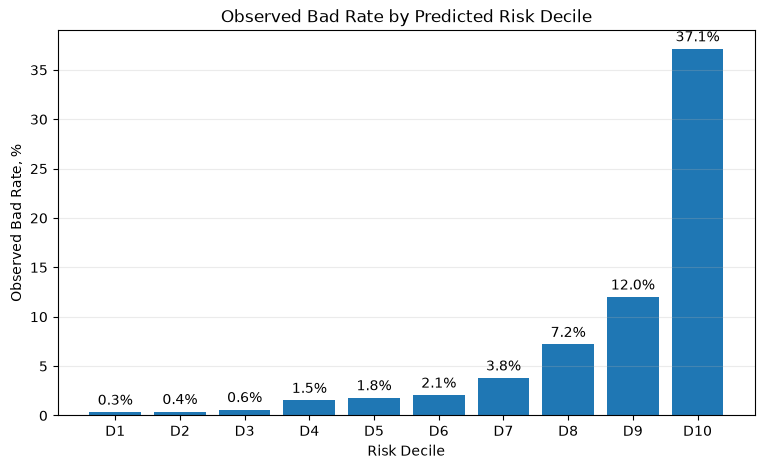

In [266]:
observed_bad_rate_by_risk_decile(
    risk_groups=risk_groups
)

Observed bad rate монотонно возрастает от низких risk deciles к высоким: от 0,33% в D1 до 37,13% в D10. Это показывает, что модель эффективно разделяет заёмщиков по уровню относительного риска на final holdout. При этом predicted risk scores систематически превышают observed bad rate, поэтому выход модели следует интерпретировать как risk score, а не как откалиброванную probability of default.

# Выводы

1. Обе модели демонстрируют хорошее качество risk ranking на final holdout. CatBoost превосходит Logistic Regression по всем рассматриваемым discrimination metrics: ROC-AUC, Gini, KS и PR-AUC. Прирост умеренный в абсолютном выражении, но устойчивый по всем метрикам, поэтому CatBoost выбран как основная scoring model.
2. Logistic Regression сохраняет ценность как интерпретируемый baseline. Направления её крупнейших коэффициентов в целом согласуются с risk patterns, выявленными в предыдущем анализе, что служит дополнительным sanity check модели.
3. CatBoost обеспечивает выраженное разделение портфеля по риску: observed bad rate монотонно возрастает от 0,33% в D1 до 37,13% в D10. Это подтверждает пригодность score для дальнейшей portfolio risk segmentation.
4. Поскольку predicted scores не откалиброваны относительно observed bad rate, они интерпретируются как относительный risk score, а не как calibrated probability of default.
5. Следующим этапом анализа является использование borrower-level scores для decile analysis, risk grades и credit-policy cutoff analysis.